In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = "/kaggle/input/datasets/aadityaupadhyay1353"
OUT = "/kaggle/working/"

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

os.makedirs(OUT, exist_ok=True)

print("Visualization notebook ready")

Visualization notebook ready


In [2]:
baseline = pd.read_csv(
    f"{BASE}/v2-baseline-results/v2_model_baseline_results.csv"
)

aggregation = pd.read_csv(
    f"{BASE}/v2-aggregation-results/v2_aggregation_comparison.csv"
)

robust_delta = pd.read_csv(
    f"{BASE}/v2-robustness-results/v2_robustness_delta.csv"
)

summary = pd.read_csv(
    f"{BASE}/v2-statistical-results/robustness_summary.csv"
)

comparison = pd.read_csv(
    f"{BASE}/v2-statistical-results/model_comparison_table.csv"
)

print("Datasets loaded")

Datasets loaded


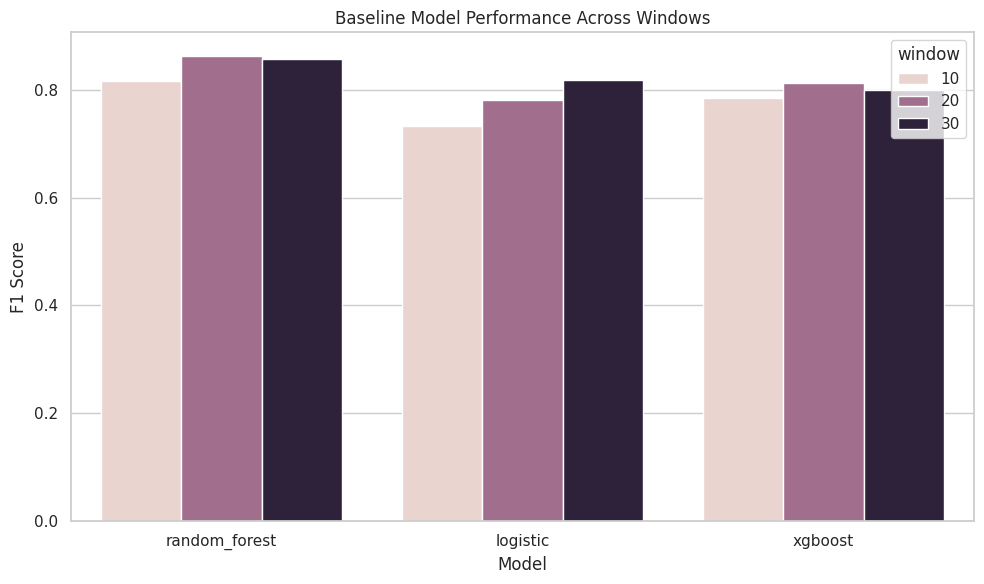

In [3]:
plt.figure()

sns.barplot(
    data=baseline,
    x="model",
    y="f1",
    hue="window"
)

plt.title("Baseline Model Performance Across Windows")
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.tight_layout()

plt.savefig(f"{OUT}/figure_baseline_models.png", dpi=300)

plt.show()

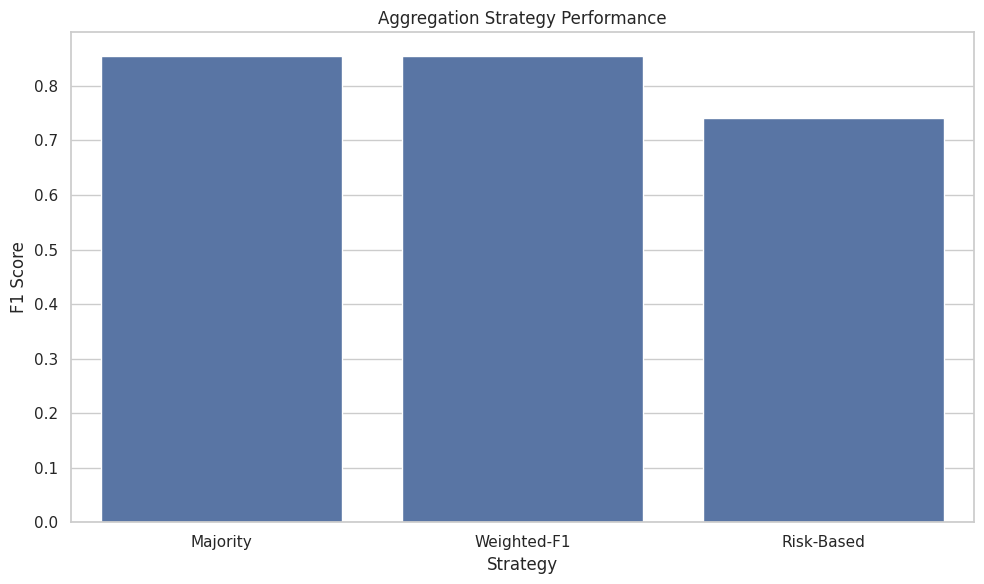

In [4]:
plt.figure()

sns.barplot(
    data=aggregation,
    x="strategy",
    y="f1",
)

plt.title("Aggregation Strategy Performance")
plt.ylabel("F1 Score")
plt.xlabel("Strategy")

plt.tight_layout()

plt.savefig(f"{OUT}/figure_aggregation_strategies.png", dpi=300)

plt.show()

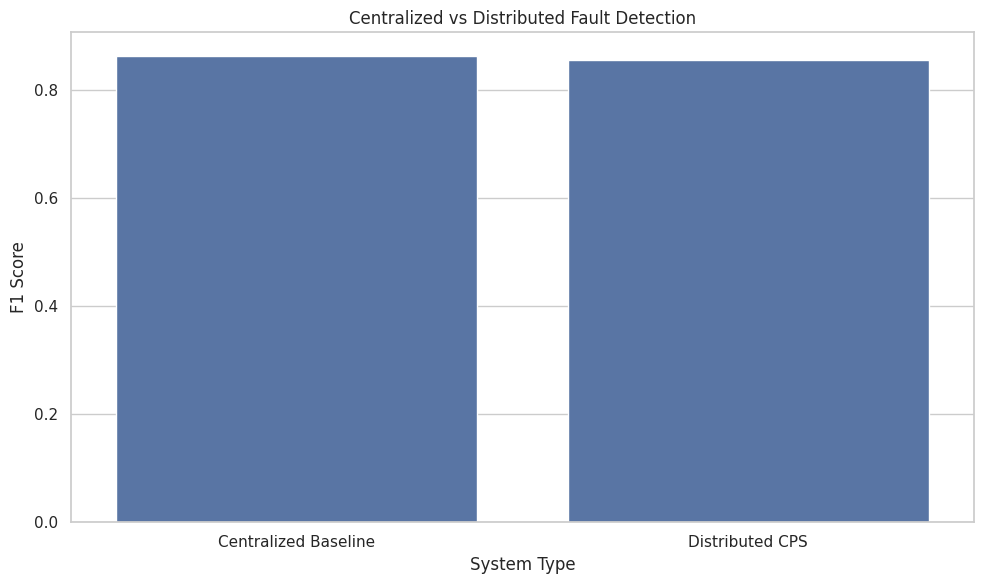

In [5]:
plt.figure()

sns.barplot(
    data=comparison,
    x="model_type",
    y="f1"
)

plt.title("Centralized vs Distributed Fault Detection")
plt.ylabel("F1 Score")
plt.xlabel("System Type")

plt.tight_layout()

plt.savefig(f"{OUT}/figure_system_comparison.png", dpi=300)

plt.show()

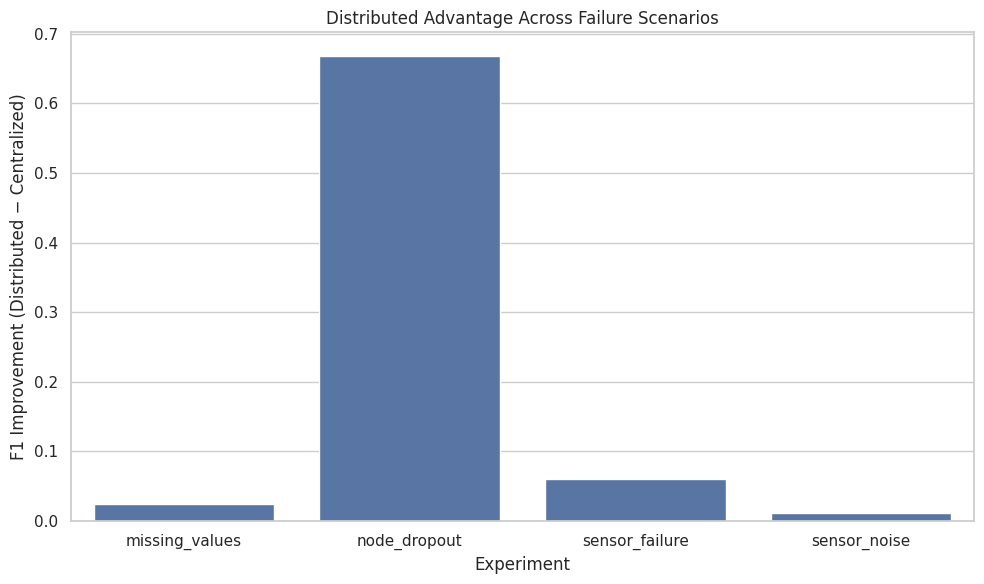

In [6]:
plt.figure()

sns.barplot(
    data=summary,
    x="experiment",
    y="f1_delta"
)

plt.title("Distributed Advantage Across Failure Scenarios")
plt.ylabel("F1 Improvement (Distributed − Centralized)")
plt.xlabel("Experiment")

plt.tight_layout()

plt.savefig(f"{OUT}/figure_robustness_advantage.png", dpi=300)

plt.show()

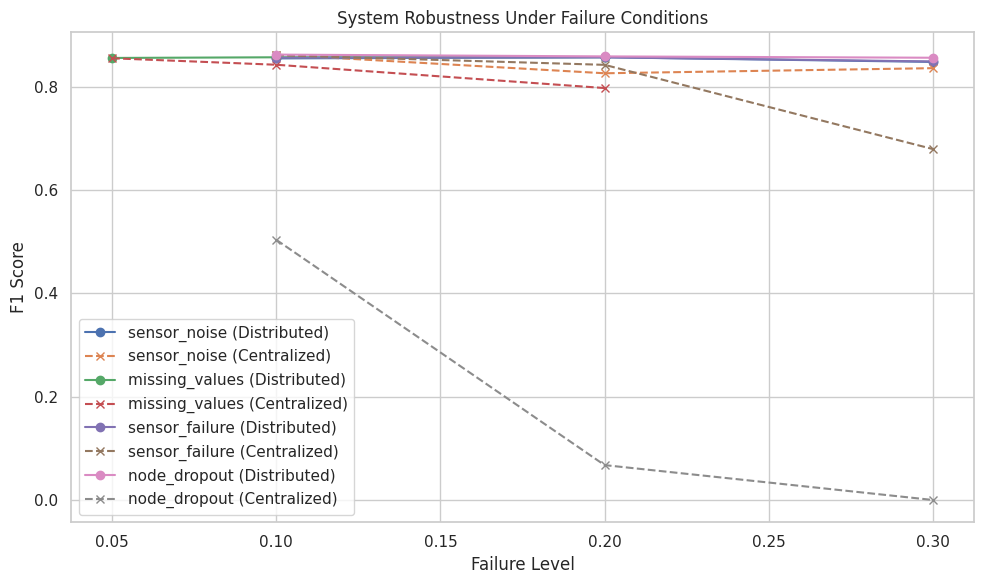

In [7]:
plt.figure()

for exp in robust_delta["experiment"].unique():

    subset = robust_delta[robust_delta["experiment"] == exp]

    plt.plot(
        subset["level"],
        subset["f1_dist"],
        marker="o",
        label=f"{exp} (Distributed)"
    )

    plt.plot(
        subset["level"],
        subset["f1_cent"],
        marker="x",
        linestyle="--",
        label=f"{exp} (Centralized)"
    )

plt.title("System Robustness Under Failure Conditions")
plt.xlabel("Failure Level")
plt.ylabel("F1 Score")

plt.legend()

plt.tight_layout()

plt.savefig(f"{OUT}/figure_robustness_curves.png", dpi=300)

plt.show()

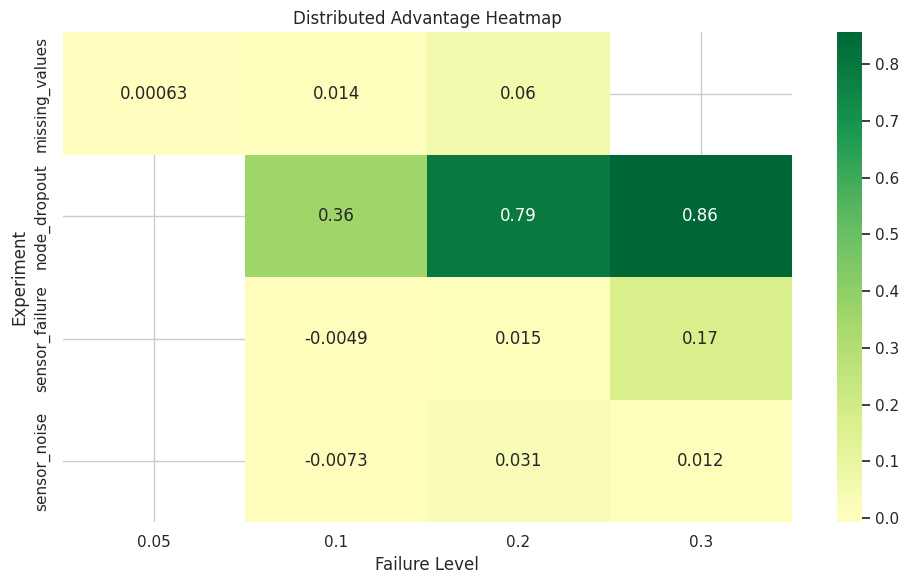

In [8]:
pivot = robust_delta.pivot(
    index="experiment",
    columns="level",
    values="f1_delta"
)

plt.figure()

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn",
    center=0
)

plt.title("Distributed Advantage Heatmap")
plt.xlabel("Failure Level")
plt.ylabel("Experiment")

plt.tight_layout()

plt.savefig(f"{OUT}/figure_delta_heatmap.png", dpi=300)

plt.show()

In [9]:
!ls -lh /kaggle/working/

total 1.2M
-rw-r--r-- 1 root root  92K Apr 12 14:31 figure_aggregation_strategies.png
-rw-r--r-- 1 root root  99K Apr 12 14:31 figure_baseline_models.png
-rw-r--r-- 1 root root 166K Apr 12 14:31 figure_delta_heatmap.png
-rw-r--r-- 1 root root 117K Apr 12 14:31 figure_robustness_advantage.png
-rw-r--r-- 1 root root 261K Apr 12 14:31 figure_robustness_curves.png
-rw-r--r-- 1 root root  87K Apr 12 14:31 figure_system_comparison.png
---------- 1 root root 313K Apr 12 14:31 __notebook__.ipynb
